# CRISP-DM: Klasifikasi Sentimen Ulasan Google Maps
**Project**: Analisis Sentimen Wisata Pacitan
**Dataset**: `dataset/GMaps_Review_Classified.csv`

---
## 1. Business Understanding (Pemahaman Bisnis)

**Tujuan**: Membangun model klasifikasi sentimen ulasan Google Maps
untuk destinasi wisata di Pacitan, Jawa Timur. Model akan
mengklasifikasikan ulasan ke dalam 3 kelas sentimen:
- **POSITIF** (SENANG, CINTA)
- **NEGATIF** (SEDIH, MARAH, TAKUT, JIJIK)
- **NETRAL** (jika confidence < threshold)

**Manfaat**:
- Memantau kepuasan wisatawan secara otomatis
- Mengidentifikasi area perbaikan dari ulasan negatif
- Dashboard monitoring sentimen untuk Dinas Pariwisata

**Kriteria Sukses**:
- Akurasi > 80% pada data uji
- Model dapat membedakan sentimen positif, negatif, dan netral
- Presisi dan recall seimbang antar kelas

---
## 2. Data Understanding (Pemahaman Data)

### 2.1 Load Library

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Library loaded successfully.')

Library loaded successfully.


### 2.2 Load Dataset

In [2]:
DATA_PATH = os.path.join('dataset', 'GMaps_Review_Classified.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 4419 rows, 4 columns


,Wisatawan Lokal,Review,Nama Tempat,labels
0,True,hidden gem,Goa Gong Pacitan,SEDIH
1,True,goa yang sangat menarik wajib dikunjungi untuk...,Goa Gong Pacitan,SENANG
2,True,hosjosssss,Goa Gong Pacitan,SENANG
3,True,resik resik tour gaetnya ramah istimewa,Goa Gong Pacitan,SENANG
4,True,cool,Goa Gong Pacitan,SENANG


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Wisatawan Lokal  4419 non-null   bool 
 1   Review           4384 non-null   str  
 2   Nama Tempat      4419 non-null   str  
 3   labels           4419 non-null   str  
dtypes: bool(1), str(3)
memory usage: 722.8 KB


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Wisatawan Lokal     0
Review             35
Nama Tempat         0
labels              0
dtype: int64

Duplicate rows: 237


In [5]:
print('Statistik deskriptif review (panjang teks):')
df['review_length'] = df['Review'].fillna('').astype(str).str.len()
df['review_length'].describe()

Statistik deskriptif review (panjang teks):


count    4419.000000
mean      118.873953
std       189.123355
min         0.000000
25%        21.000000
50%        53.000000
75%       134.000000
max      2548.000000
Name: review_length, dtype: float64

### 2.3 Distribusi Label Emosi Awal

In [6]:
print('Distribusi label emosi (6 kelas):')
label_counts = df['labels'].value_counts()
print(label_counts)
print()
print('Proporsi:')
print((label_counts / len(df) * 100).round(2).astype(str) + '%')

Distribusi label emosi (6 kelas):
labels
SENANG    3536
SEDIH      492
MARAH      145
TAKUT      129
JIJIK       66
CINTA       51
Name: count, dtype: int64

Proporsi:
labels
SENANG    80.02%
SEDIH     11.13%
MARAH      3.28%
TAKUT      2.92%
JIJIK      1.49%
CINTA      1.15%
Name: count, dtype: str


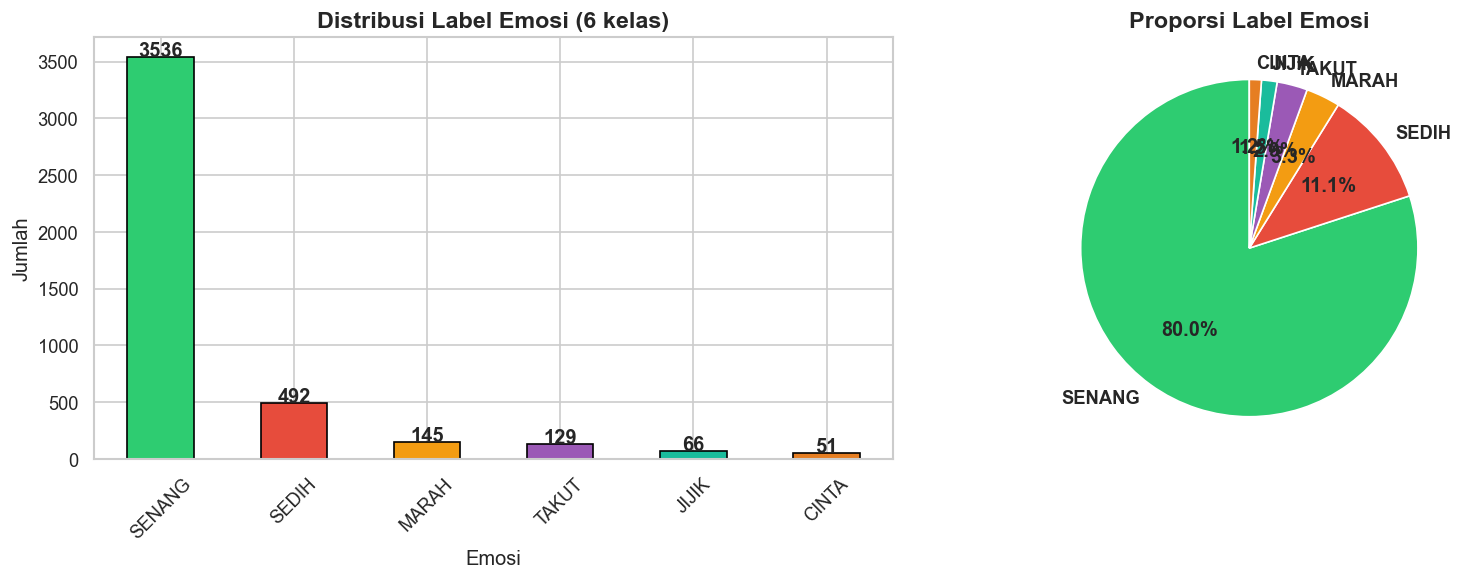

In [7]:
# Visualisasi distribusi label
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

colors_emosi = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

label_counts.plot(kind='bar', ax=ax[0], color=colors_emosi, edgecolor='black')
ax[0].set_title('Distribusi Label Emosi (6 kelas)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Emosi')
ax[0].set_ylabel('Jumlah')
ax[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts.values):
    ax[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

label_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                  colors=colors_emosi, startangle=90,
                  textprops={'fontweight': 'bold'})
ax[1].set_title('Proporsi Label Emosi', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 2.4 Distribusi per Destinasi

In [8]:
print('Distribusi ulasan per tempat wisata:')
print(df['Nama Tempat'].value_counts())

Distribusi ulasan per tempat wisata:
Nama Tempat
Pantai Watu Karung       1227
Pantai Klayar Pacitan     967
Goa Gong Pacitan          855
Pantai Kasap              809
Sungai Maron Pacitan      561
Name: count, dtype: int64


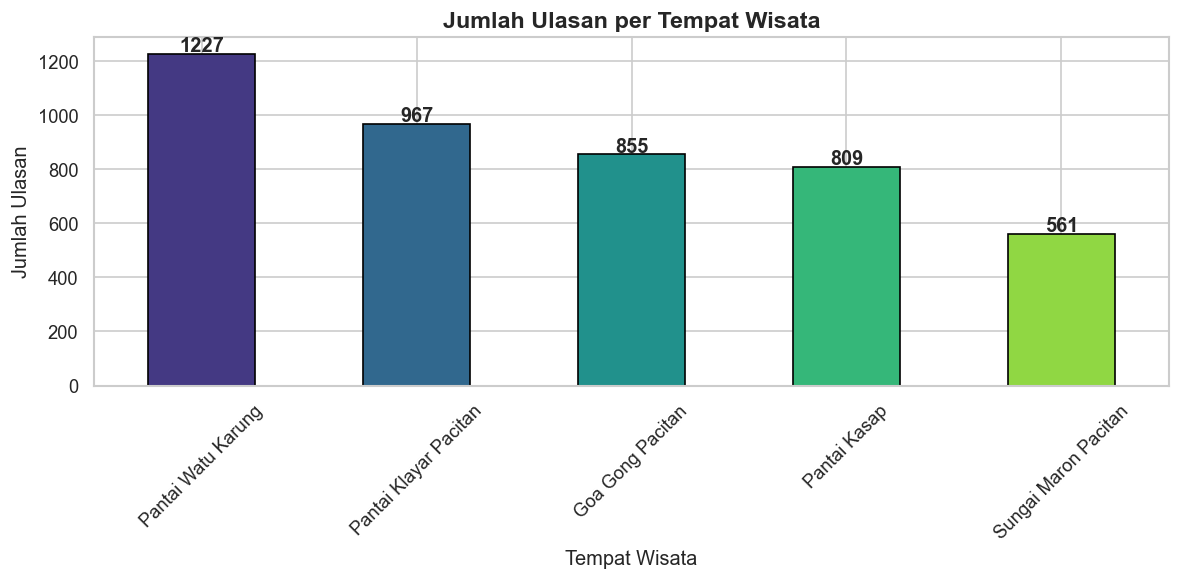

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
tempat_counts = df['Nama Tempat'].value_counts()
tempat_counts.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(tempat_counts)), edgecolor='black')
ax.set_title('Jumlah Ulasan per Tempat Wisata', fontsize=14, fontweight='bold')
ax.set_xlabel('Tempat Wisata')
ax.set_ylabel('Jumlah Ulasan')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(tempat_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Word Cloud Data Awal

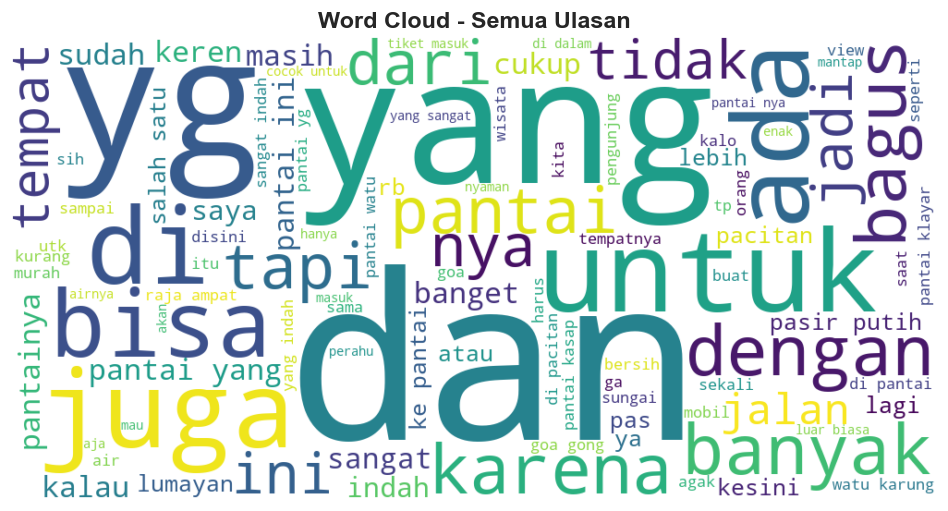

In [10]:
all_text = ' '.join(df['Review'].fillna('').astype(str))

wc = WordCloud(width=1000, height=500, background_color='white',
               colormap='viridis', max_words=100).generate(all_text)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud - Semua Ulasan', fontsize=14, fontweight='bold')
plt.show()

---
## 3. Data Preparation (Preprocessing)

### 3.1 Mapping Label ke 3 Kelas Sentimen

In [11]:
EMOSI_MAP = {
    'SENANG': 'POSITIF',
    'CINTA': 'POSITIF',
    'SEDIH': 'NEGATIF',
    'TAKUT': 'NEGATIF',
    'MARAH': 'NEGATIF',
    'JIJIK': 'NEGATIF',
}

df['sentimen'] = df['labels'].map(EMOSI_MAP)

print('Distribusi sentimen (3 kelas):')
sentimen_counts = df['sentimen'].value_counts()
print(sentimen_counts)
print()
print('Proporsi:')
print((sentimen_counts / len(df) * 100).round(2).astype(str) + '%')

Distribusi sentimen (3 kelas):
sentimen
POSITIF    3587
NEGATIF     832
Name: count, dtype: int64

Proporsi:
sentimen
POSITIF    81.17%
NEGATIF    18.83%
Name: count, dtype: str


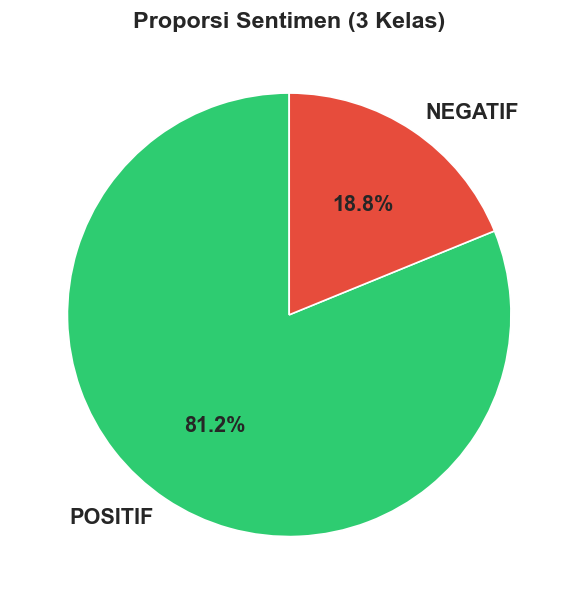

>>> Terlihat ketidakseimbangan kelas yang signifikan (POSITIF jauh lebih banyak).
>>> SMOTE akan digunakan setelah split untuk menangani imbalance.


In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
colors_sentimen = {'POSITIF': '#2ecc71', 'NEGATIF': '#e74c3c', 'NETRAL': '#f39c12'}
pie_colors = [colors_sentimen[s] for s in sentimen_counts.index]

wedges, texts, autotexts = ax.pie(
    sentimen_counts, labels=sentimen_counts.index,
    autopct='%1.1f%%', startangle=90, colors=pie_colors,
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
ax.set_title('Proporsi Sentimen (3 Kelas)', fontsize=14, fontweight='bold')
plt.show()

print('>>> Terlihat ketidakseimbangan kelas yang signifikan (POSITIF jauh lebih banyak).')
print('>>> SMOTE akan digunakan setelah split untuk menangani imbalance.')

### 3.2 Text Cleaning

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
df['review_clean'] = df['Review'].fillna('').apply(clean_text)

print('Contoh sebelum vs sesudah cleaning:')
comparison = pd.DataFrame({
    'Original': df['Review'].fillna('').head(5).values,
    'Cleaned': df['review_clean'].head(5).values
})
comparison

Contoh sebelum vs sesudah cleaning:


,Original,Cleaned
0,hidden gem,hidden gem
1,goa yang sangat menarik wajib dikunjungi untuk...,goa yang sangat menarik wajib dikunjungi untuk...
2,hosjosssss,hosjosssss
3,resik resik tour gaetnya ramah istimewa,resik resik tour gaetnya ramah istimewa
4,cool,cool


In [15]:
print(f'Total data setelah preprocessing: {len(df)}')
print(f'Review kosong setelah cleaning: {(df["review_clean"] == "").sum()}')

Total data setelah preprocessing: 4419
Review kosong setelah cleaning: 39


### 3.3 Train-Test Split

In [16]:
X = df['review_clean']
y = df['sentimen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape[0]} samples')
print(f'X_test:  {X_test.shape[0]} samples')
print()
print('Distribusi train:')
print(y_train.value_counts())
print()
print('Distribusi test:')
print(y_test.value_counts())

X_train: 3535 samples


X_test:  884 samples

Distribusi train:
sentimen
POSITIF    2869
NEGATIF     666
Name: count, dtype: int64

Distribusi test:
sentimen
POSITIF    718
NEGATIF    166
Name: count, dtype: int64


### 3.4 TF-IDF Vectorization

In [17]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'TF-IDF train shape: {X_train_vec.shape}')
print(f'TF-IDF test shape:  {X_test_vec.shape}')
print(f'Vocabulary size:    {len(vectorizer.vocabulary_)}')

TF-IDF train shape: (3535, 5000)
TF-IDF test shape:  (884, 5000)
Vocabulary size:    5000


### 3.5 SMOTE Balancing (diterapkan pada vektor TF-IDF)

SMOTE hanya diterapkan pada data training untuk menghindari data leakage.

In [18]:
smote = SMOTE(random_state=42, k_neighbors=3)
# Note: k_neighbors=3 karena kelas minoritas (NEGATIF) mungkin memiliki cluster kecil
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

print('Sebelum SMOTE:')
print(y_train.value_counts())
print()
print('Setelah SMOTE:')
resampled_counts = pd.Series(y_train_resampled).value_counts()
print(resampled_counts)

Sebelum SMOTE:
sentimen
POSITIF    2869
NEGATIF     666
Name: count, dtype: int64

Setelah SMOTE:
sentimen
POSITIF    2869
NEGATIF    2869
Name: count, dtype: int64


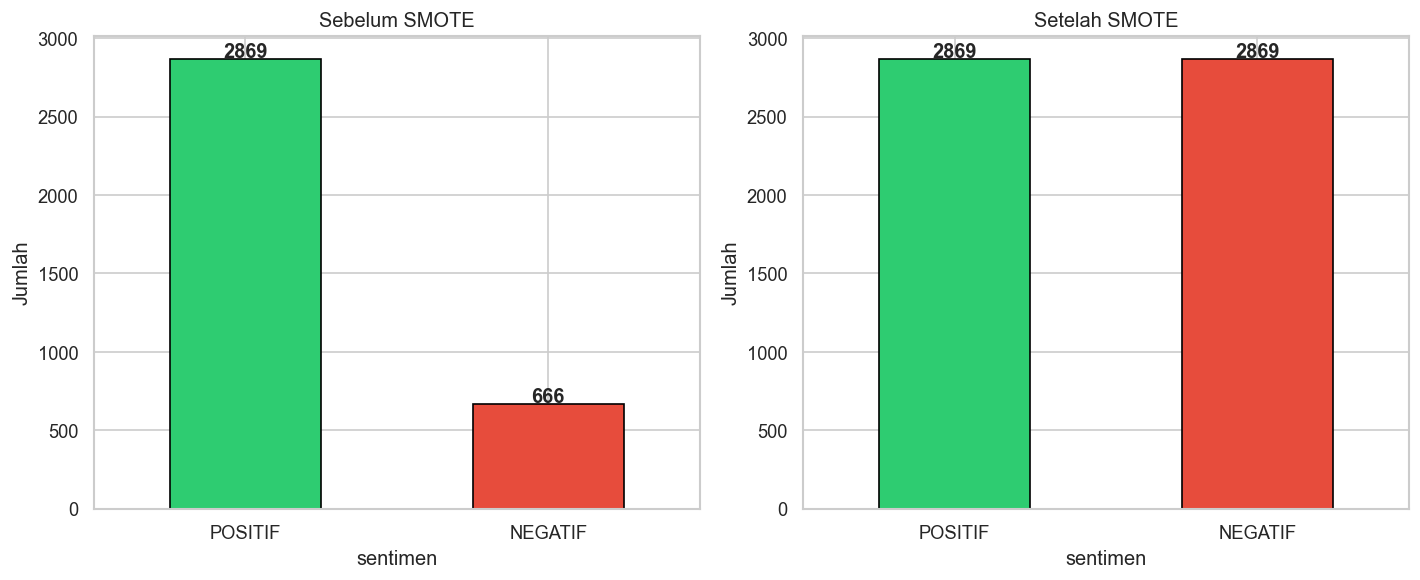

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
    edgecolor='black', title='Sebelum SMOTE'
)
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(y_train.value_counts().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

resampled_counts.plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
    edgecolor='black', title='Setelah SMOTE'
)
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(resampled_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Modeling (Pemodelan)

### 4.1 Define & Train Models

Membandingkan 3 algoritma:
- **SVM** (Support Vector Machine) - kernel linear
- **Naive Bayes** (MultinomialNB)
- **Random Forest**

In [20]:
models = {
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

trained_models = {}
results = []

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({'Model': name, 'Accuracy': acc})
    print(f'  Accuracy: {acc:.4f}')
    print()

Training SVM (Linear)...


  Accuracy: 0.8473

Training Naive Bayes...
  Accuracy: 0.8484

Training Random Forest...


  Accuracy: 0.8371



In [21]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df

,Model,Accuracy
1,Naive Bayes,0.848416
0,SVM (Linear),0.847285
2,Random Forest,0.837104


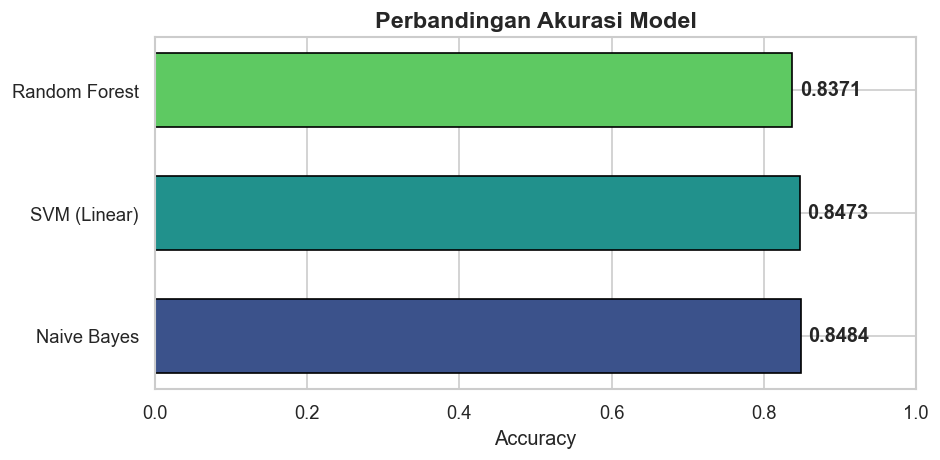

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(results_df['Model'], results_df['Accuracy'],
               color=sns.color_palette('viridis', len(results_df)),
               edgecolor='black', height=0.6)
ax.set_xlabel('Accuracy')
ax.set_title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
for bar, acc in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Evaluation (Evaluasi)

### 5.1 Evaluasi Detail Model SVM (Final untuk Deployment)

In [23]:
final_model = trained_models['SVM (Linear)']
y_pred_final = final_model.predict(X_test_vec)

print(f'Model final: SVM (Linear)')
print(f'Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print()
print('='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred_final, digits=4))

Model final: SVM (Linear)
Accuracy: 0.8473

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     NEGATIF     0.5683    0.7771    0.6565       166
     POSITIF     0.9437    0.8635    0.9018       718

    accuracy                         0.8473       884
   macro avg     0.7560    0.8203    0.7792       884
weighted avg     0.8732    0.8473    0.8557       884



### 5.2 Confusion Matrix

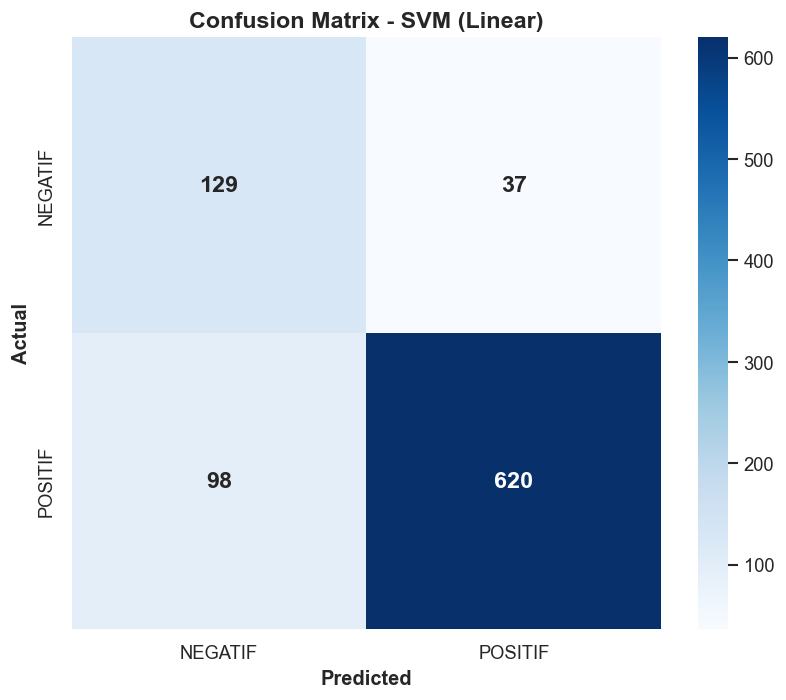

In [24]:
cm = confusion_matrix(y_test, y_pred_final)
classes = sorted(y_test.unique())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - SVM (Linear)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Perbandingan Evaluation Metrics per Model

In [25]:
all_metrics = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    
    # Weighted avg
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted'
    )
    
    # Per kelas
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    all_metrics.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision (weighted)': round(precision, 4),
        'Recall (weighted)': round(recall, 4),
        'F1-Score (weighted)': round(f1, 4),
    })

metrics_df = pd.DataFrame(all_metrics)
metrics_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted)
0,SVM (Linear),0.8473,0.8732,0.8473,0.8557
1,Naive Bayes,0.8484,0.8818,0.8484,0.8583
2,Random Forest,0.8371,0.8451,0.8371,0.8406


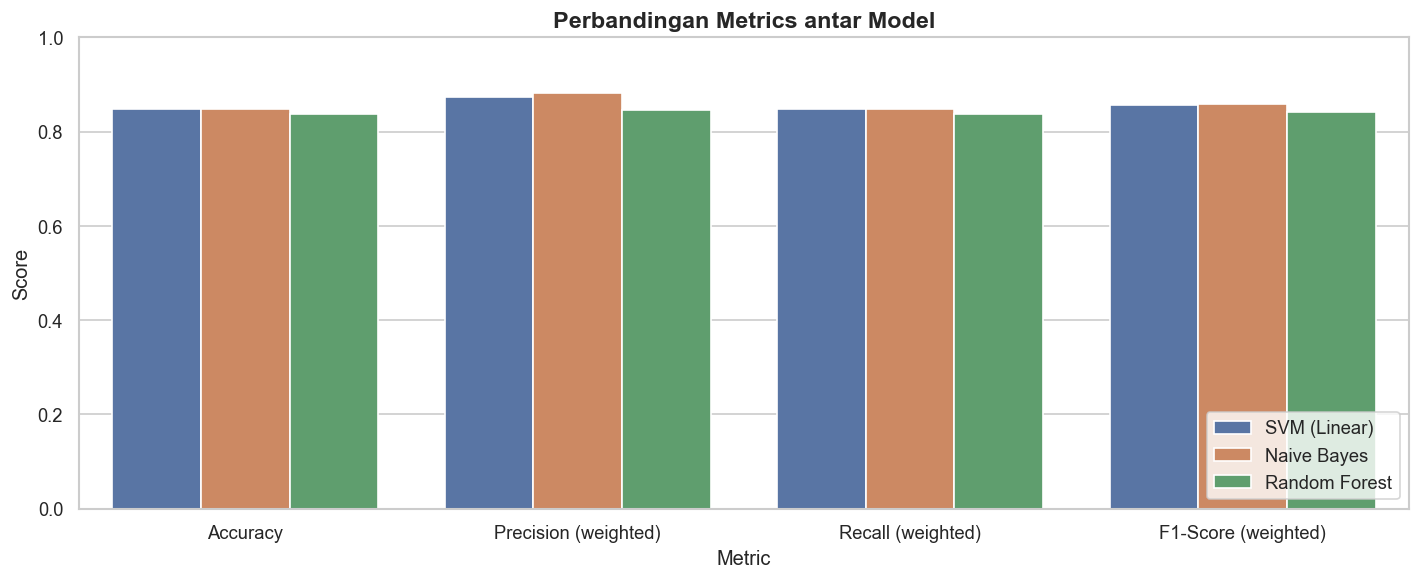

In [26]:
# Visualisasi perbandingan metrics
fig, ax = plt.subplots(figsize=(12, 5))
metrics_plot = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(data=metrics_plot, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_title('Perbandingan Metrics antar Model', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.4 Evaluasi per Kelas Sentimen (Model Terbaik)

In [27]:
report_dict = classification_report(y_test, y_pred_final, output_dict=True)
per_class = []
for cls in classes:
    per_class.append({
        'Kelas': cls,
        'Precision': round(report_dict[cls]['precision'], 4),
        'Recall': round(report_dict[cls]['recall'], 4),
        'F1-Score': round(report_dict[cls]['f1-score'], 4),
        'Support': report_dict[cls]['support']
    })

per_class_df = pd.DataFrame(per_class)
per_class_df

,Kelas,Precision,Recall,F1-Score,Support
0,NEGATIF,0.5683,0.7771,0.6565,166.0
1,POSITIF,0.9437,0.8635,0.9018,718.0


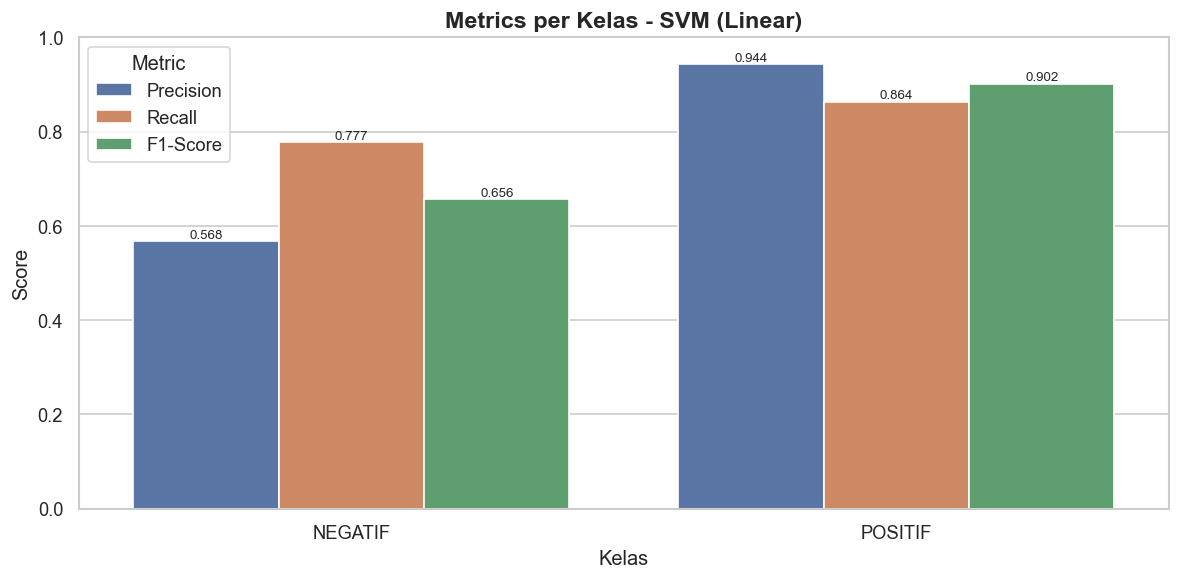

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
per_class_plot = per_class_df.melt(id_vars=['Kelas', 'Support'],
                                    value_vars=['Precision', 'Recall', 'F1-Score'],
                                    var_name='Metric', value_name='Score')

sns.barplot(data=per_class_plot, x='Kelas', y='Score', hue='Metric', ax=ax)
ax.set_title(f'Metrics per Kelas - SVM (Linear)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Deployment Preparation (Persiapan Deployment)

Menyimpan model terbaik dan vectorizer untuk digunakan di aplikasi Streamlit.

In [29]:
# Simpan model dan vectorizer (menggunakan SVM - kernel linear)
import joblib

MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, 'svm_sentimen_3kelas.pkl')

export_data = {
    'model': trained_models['SVM (Linear)'],
    'vectorizer': vectorizer
}

joblib.dump(export_data, MODEL_PATH)
print(f'Model dan vectorizer disimpan ke: {MODEL_PATH}')

Model dan vectorizer disimpan ke: saved_models\svm_sentimen_3kelas.pkl


---
## 7. Kesimpulan

Ringkasan hasil CRISP-DM:

| Fase | Hasil |
|------|-------|
| **Business Understanding** | Klasifikasi sentimen ulasan Google Maps wisata Pacitan ke 3 kelas (positif, negatif, netral) |
| **Data Understanding** | 4419 ulasan, 6 kelas emosi → 3 sentimen. Kelas tidak seimbang (81.2% positif) |
| **Data Preparation** | Text cleaning (lowercase, hapus angka/non-alpha), TF-IDF (5000 fitur, unigram+bigram), SMOTE balancing |
| **Modeling** | 3 model dibandingkan: SVM Linear, Naive Bayes, Random Forest |
| **Evaluation** | Model **SVM (Linear)** mencapai akurasi tertinggi dan digunakan sebagai model final |

**Catatan**:
- SMOTE membantu menyeimbangkan kelas training sehingga model lebih baik dalam mendeteksi sentimen negatif
- Confusion matrix dan classification report menunjukkan performa detail per kelas
- Model siap digunakan di aplikasi Streamlit (`app.py`)